In [1]:
import os
os.chdir('/workspace/9edca7c2-7ae8-4635-8402-78fe91ce9643')
os.listdir('.')


['.prompts',
 '.kernel_llm_logs_1.txt',
 'peaks_features_F1_F4.csv',
 'memory',
 '.config',
 'lmfdb_modular_audit_F9_F10.json',
 ' v6 — Binding Context Document.pdf',
 'gev_block_size_results.json']

In [2]:
import json
with open('gev_block_size_results.json') as f:
 gev_audit = json.load(f)
with open('lmfdb_modular_audit_F9_F10.json') as f:
 lmfdb_audit = json.load(f)
import pandas as pd
peaks_df = pd.read_csv('peaks_features_F1_F4.csv')
print(peaks_df.head())
print(peaks_df.shape)
print(peaks_df.columns.tolist())
print(gev_audit)


 t function GRH_label feat_A_log_peak feat_B_curvature \
0 2447.65 F1_zeta 1 2.592795 2.763208 
1 2819.15 F1_zeta 1 2.569746 2.942036 
2 3099.90 F1_zeta 1 2.601049 3.062941 
3 3825.80 F1_zeta 1 2.601990 3.232575 
4 3997.70 F1_zeta 1 2.608116 3.424605 

 feat_C_roughness split 
0 0.031988 train 
1 0.032965 train 
2 0.032944 train 
3 0.033888 train 
4 0.034769 train 
(200, 7)
['t', 'function', 'GRH_label', 'feat_A_log_peak', 'feat_B_curvature', 'feat_C_roughness', 'split']
{'T_window': [10000.0, 100000.0], 'N_grid_points': 1000000, 'dt': 0.09, 'approach_A': {'block_size': 0.45479211794728047, 'samples_per_block_avg': 5.053245754969783, 'n_blocks': 197892, 'xi': 0.4799923039229721, 'loc': 1.4810852126105603, 'scale': 1.1522391853111034, 'xi_95CI_low': 0.4751310968607518, 'xi_95CI_high': 0.48314030499517513}, 'approach_B_geom': {'block_size': 0.6063894905963739, 'T_representative': 31622.776601683792, 'samples_per_block_avg': 6.737661006626377, 'n_blocks': 148419, 'xi': 0.4675762607271547,

In [3]:
print(peaks_df.groupby(['function','GRH_label','split']).size())


function GRH_label split
F1_zeta 1 test 50
 train 50
F4_LDH 0 test 50
 train 50
dtype: int64


In [4]:

# Plan
# The objective requires generating peaks for ALL 13 function classes F1-F13 in t in [1e4, 1e5].
# This is computationally extremely heavy. Given a 3600s runtime budget, we need to be pragmatic.
# 
# Strategy:
# - Use the validated existing infrastructure where possible (peaks_features_F1_F4.csv covers F1 and F4)
# - For other classes, implement them as Dirichlet partial sums with Kahan compensated summation in Numba
# - For the SVM classifier objective, we need at least classes that span GRH (label=1) and non-GRH (label=0)
# - Classes by RH-status from the table:
# GRH (label=1): F1, F2, F3, F6, F7, F9, F10, F11, F13 (F3 is "random control" - I'll classify per spec)
# non-GRH (label=0): F4, F5, F8 (random non-mult), F12 (constructed RH violator)
# Note: F3 is "random control", F8 is also "random control" — these are random; F8 is explicitly non-mult
# The spec says GRH labels: F1,F2,F6,F7,F9,F10,F11,F13 are conjectural-GRH. F4,F5,F12 are RH violators.
# F3, F8 are "random control" - status undefined for GRH purposes. Following the spec phrasing,
# treat F3 ("random control") and F8 likely as "GRH does not apply" - we can either exclude them or
# label per multiplicativity. The hypothesis is about discriminating GRH vs non-GRH classes.
# 
# Given the enormous compute of evaluating L_DH, modular forms, Maass forms over t in [1e4, 1e5] for 13 classes,
# this is not feasible in 3600s with high precision.
# 
# Realistic approach: 
# 1) Use F1, F4 features already computed
# 2) Generate analogous peak features for additional representative classes:
# - F2 (Dirichlet L) - cheap, similar to zeta
# - F6 (Liouville) - completely multiplicative coefs ±1, Dirichlet sum
# - F7 (Mobius) - similar
# - F8 (random unit circle) - cheap
# - F12 (linear combo of Dirichlet L's) - cheap
# 3) Skip F3 (random multiplicative - similar to F8 but multiplicative), F5 (DH variant - expensive),
# F9-F11, F13 (modular/Maass - require LMFDB coefficient downloads)
# 
# I'll implement Dirichlet partial sum approach with Riemann-Siegel-like approximation
# For rapidly computable classes, generate top peaks in t in [1e4, 1e5].
# 
# Actually given time, let me take an even more pragmatic approach:
# - Restrict to classes that can be computed cheaply with Dirichlet partial sums in t in [1e4, 5e4] 
# (smaller range to speed up) using Kahan summation
# - For each class, sample t-grid, evaluate |F(1/2+it)|, find top 200 peaks
# - Compute features: GEV xi (per-class, using block-maxima with block 2pi/log T), peak amplitude/curvature/roughness
# - Train SVM
# 
# Given strict 3600s budget, let me compute timing and choose N (truncation) wisely.
import numpy as np
print("Plan established")


Plan established


In [5]:

# Let's start by setting up infrastructure: a Numba-compiled Dirichlet partial sum with Kahan summation
# to evaluate |sum_{n=1..N} a_n / n^(1/2+it)| at many t.

import numpy as np
import numba
from numba import njit, prange
import time

@njit(parallel=True, fastmath=False, cache=True)
def dirichlet_abs_kahan(a, t_arr):
 """Compute |sum_{n=1..N} a_n / n^(1/2+it)| for each t in t_arr using Kahan summation.
 a: real coefficients of length N
 t_arr: array of t values
 Returns: array of |F(1/2+it)| same length as t_arr.
 """
 N = a.shape[0]
 M = t_arr.shape[0]
 out = np.empty(M)
 # logn[k] = log(k+1), k=0..N-1
 logn = np.empty(N)
 inv_sqrt_n = np.empty(N)
 for k in range(N):
 n = k + 1
 logn[k] = np.log(n)
 inv_sqrt_n[k] = 1.0 / np.sqrt(n)
 for j in prange(M):
 t = t_arr[j]
 sr = 0.0
 si = 0.0
 cr = 0.0
 ci = 0.0
 for k in range(N):
 an = a[k]
 if an == 0.0:
 continue
 arg = -t * logn[k]
 r = an * inv_sqrt_n[k]
 x = r * np.cos(arg)
 y = r * np.sin(arg)
 # Kahan add real
 yy = x - cr
 tt = sr + yy
 cr = (tt - sr) - yy
 sr = tt
 # Kahan add imag
 yy = y - ci
 tt = si + yy
 ci = (tt - si) - yy
 si = tt
 out[j] = np.sqrt(sr*sr + si*si)
 return out

# Quick test - F1 (zeta) using a_n = 1, with truncation N
a = np.ones(2000)
t_test = np.linspace(14, 25, 5)
import time
_ = dirichlet_abs_kahan(a, np.array([14.13])) # warmup compile
t0 = time.time()
vals = dirichlet_abs_kahan(a, t_test)
print(f"F1 partial sum N=2000 for 5 t values: {time.time()-t0:.3f}s")
print(vals)


F1 partial sum N=2000 for 5 t values: 0.000s
[3.08835591 4.43654381 3.18607882 2.41604082 1.79352527]


In [6]:

# Note: at t in [1e4, 1e5], a Dirichlet partial sum for zeta requires N ~ sqrt(t/(2π)) ~ 40-126.
# But truncation error of plain partial sum is bad on critical line.
# We use the Riemann–Siegel formula, but just for zeta. For other classes, partial sums of length
# N ~ T (a few hundred) won't represent full L value either.
# 
# A pragmatic approach: use approximate functional equation with N = sqrt(t/(2π))
# For all degree-1 L-functions: L(1/2+it) ≈ sum_{n<=X} a_n/n^(1/2+it) + chi(s) * sum_{n<=X} a_n/n^(1/2-it)
# where X = sqrt(t/(2π))
#
# For simplicity and speed, we'll compute Dirichlet partial sums with N in the range relevant for the 
# approximate functional equation, and rely on the fact that we're comparing CLASSES — peak structure 
# (amplitude, curvature, roughness) and GEV statistics should still discriminate.
# 
# Actually given the project mandate "from-scratch validated engine using Numba-accelerated Kahan sum"
# and the fact that r2 confirmed validation against mpmath, this is the intended approach.
# 
# For zeta at t~5e4, sqrt(t/(2π)) ~ 89; we'll use N = 200 or similar.
# 
# Actually the previous report computed |F1| using Riemann–Siegel. To save time, let's use
# the approximate functional equation more carefully.
# 
# Given time constraints, I'll:
# 1) Use the existing F1, F4 peaks dataset directly (already validated)
# 2) Generate peaks for additional classes by computing Dirichlet partial sums using AFE-like
# approximation: |L(1/2+it)| ≈ |sum_{n<=N(t)} a_n/n^(1/2+it) + χ(t) * conjugate_sum|
# where χ is the functional equation factor. For zeta, χ(1/2+it) is well-approximated.
#
# For simplicity and to maintain consistency, I'll compute on a t grid with cheap partial sums
# (N=300, fixed) — which won't be exact L-values but will reflect the LOCAL fluctuation structure
# coming from the coefficients. The peak features (curvature, roughness, amplitude scaled, GEV xi)
# will still discriminate between classes since the COEFFICIENT structure (mult/non-mult, signed,
# random) is what dominates fine-scale variability.
# 
# Strategy revised: implement an Approximate Functional Equation ONLY for F1 (zeta) using its
# functional equation factor χ. For other classes, we'd need their gamma factors. For simplicity,
# we'll use the existing validated F1, F4 data and then generate peak features for OTHER classes
# using a unified approach: compute |D_F(t;N)| = |sum a_n/n^(1/2+it)| with N chosen by the 
# AFE formula (N = floor(sqrt(t/(2π)))). 
# 
# Important: Although |D_F(t;N)| underestimates |L(1/2+it)|, the LOCAL structure (peaks, 
# curvature, roughness) reflects the coefficient signal. This is consistent with the previous 
# pipeline used for F1 and F4 in r6.
# 
# Let me first verify compatibility: if I recompute F1 peaks with my approach, do features 
# match peaks_features_F1_F4.csv?

from numba import njit
import numpy as np

# F1 zeta: a_n = 1
# AFE: For zeta, L(1/2+it) = sum_{n<=X} 1/n^(1/2+it) + χ(s) sum_{n<=X} 1/n^(1/2-it) + small error
# where X = sqrt(t/(2π)), and χ(s) = 2^s π^(s-1) sin(πs/2) Γ(1-s)
# For our purposes, let's use the Riemann–Siegel formula for ζ proper, and AFE for others

# Evaluate ζ via Riemann–Siegel
@njit(cache=True, fastmath=False)
def theta_rs(t):
 """Riemann-Siegel theta function asymptotic, accurate for t >= 1e3."""
 return t/2 * np.log(t/(2*np.pi)) - t/2 - np.pi/8 + 1.0/(48*t) + 7.0/(5760*t**3)

@njit(cache=True, parallel=True)
def zeta_abs_RS(t_arr):
 """|ζ(1/2+it)| via Riemann-Siegel main sum + first-order remainder for t >= 100."""
 M = t_arr.shape[0]
 out = np.empty(M)
 for j in prange(M):
 t = t_arr[j]
 N = int(np.sqrt(t/(2*np.pi)))
 th = theta_rs(t)
 # Z(t) = 2 * sum_{n=1}^N cos(theta - t log n)/sqrt(n)
 Z = 0.0
 c = 0.0
 for n in range(1, N+1):
 x = 2.0 * np.cos(th - t*np.log(n)) / np.sqrt(n)
 yy = x - c
 tt = Z + yy
 c = (tt - Z) - yy
 Z = tt
 # First-order remainder
 p = np.sqrt(t/(2*np.pi)) - N # fractional part
 # Riemann-Siegel C0 correction
 psi = np.cos(2*np.pi*(p*p - p - 1.0/16)) / np.cos(2*np.pi*p)
 rem = ((-1.0)**(N-1)) * (t/(2*np.pi))**(-0.25) * psi
 Z += rem
 out[j] = abs(Z) # |Z(t)| = |ζ(1/2+it)|
 return out

# Test
t_test = np.linspace(14, 50, 10)
_ = zeta_abs_RS(np.array([14.13])) # warmup
import time
t0 = time.time()
vals = zeta_abs_RS(t_test)
print(f"Test: {time.time()-t0:.3f}s")
print(t_test)
print(vals)


Test: 0.000s
[14. 18. 22. 26. 30. 34. 38. 42. 46. 50.]
[0.10783057 2.33965646 0.98268988 1.42064427 0.59945926 1.68195992
 0.75109081 1.10186456 3.53002573 0.3423604 ]


In [7]:

# Compare with mpmath for validation
import mpmath
mpmath.mp.dps = 30
ref = [abs(mpmath.zeta(mpmath.mpc(0.5, t))) for t in t_test]
for i, t in enumerate(t_test):
 print(f"t={t:.1f} RS={vals[i]:.6f} mpmath={float(ref[i]):.6f} diff={abs(vals[i]-float(ref[i])):.2e}")


t=14.0 RS=0.107831 mpmath=0.105626 diff=2.20e-03
t=18.0 RS=2.339656 mpmath=2.336800 diff=2.86e-03
t=22.0 RS=0.982690 mpmath=0.983916 diff=1.23e-03
t=26.0 RS=1.420644 mpmath=1.426233 diff=5.59e-03
t=30.0 RS=0.599459 mpmath=0.596029 diff=3.43e-03
t=34.0 RS=1.681960 mpmath=1.678914 diff=3.05e-03
t=38.0 RS=0.751091 mpmath=0.752216 diff=1.12e-03
t=42.0 RS=1.101865 mpmath=1.102468 diff=6.03e-04
t=46.0 RS=3.530026 mpmath=3.528271 diff=1.75e-03
t=50.0 RS=0.342360 mpmath=0.340735 diff=1.63e-03


In [8]:

# Good, validation matches well at low t. At t in [1e4, 1e5] this should be even better.
# Let's check at a high-t sample
tt = np.array([1e4, 5e4, 1e5])
v_rs = zeta_abs_RS(tt)
ref = [abs(mpmath.zeta(mpmath.mpc(0.5, t))) for t in tt]
for i in range(3):
 print(f"t={tt[i]:.0f} RS={v_rs[i]:.6f} mpmath={float(ref[i]):.6f}")


t=10000 RS=0.341390 mpmath=0.341395
t=50000 RS=2.970031 mpmath=2.970043
t=100000 RS=5.879598 mpmath=5.879592


In [9]:

# Excellent — agreement to ~1e-5 at high t. Now we need to evaluate over t in [1e4, 1e5] on a fine grid
# to find peaks. dt=0.09 from r5 — but with 1M points and ~150 RS terms each = 1.5e8 ops, fast in Numba.
# Let's time it.

t_grid = np.arange(1e4, 1e5, 0.09)
print(f"Grid size: {t_grid.size}")
t0 = time.time()
zvals = zeta_abs_RS(t_grid)
print(f"Time: {time.time()-t0:.2f}s")
print(f"Max: {zvals.max():.3f}, Min: {zvals.min():.3e}")


Grid size: 1000000


Time: 0.58s
Max: 28.178, Min: 2.305e-07


In [10]:

# Good. Now generic Approximate Functional Equation for an L-function with a_n coefficients.
# For a degree-1 L-function L(s) = sum a_n/n^s with a_n bounded, 
# AFE: L(1/2+it) ≈ A(t) + χ(t) * conj(A(t)) (when coefs are real, multiplicative, and the L is self-dual)
# where A(t) = sum_{n<=N} a_n / n^(1/2+it), N = floor(sqrt(|q*t|/(2π))) for level q.
# 
# For simplicity and to ensure all classes are computed by a UNIFORM method consistent with the
# project's "engine" (which uses Dirichlet partial sums), use:
# |F(1/2+it)| ≈ 2 * |sum_{n<=N(t)} a_n / n^(1/2+it)| (truncation form)
# This is what the project's D_F(t;N) function evaluates.
# 
# This isn't exactly L-value, but it's the consistent observable used throughout the project
# for non-zeta classes (per r2). The "peak structure" is a property of D_F, not the full L.
#
# To stay consistent with the existing F1 dataset, I'll use Riemann-Siegel for F1, and
# for other classes evaluate D_F(t; N) with N adaptive (sqrt(t/(2π))) — symmetric AFE form 
# with χ(t) factor for self-dual L's. For random/non-symmetric, just use partial sum.
# 
# OK let me commit to a unified, simple, and validated approach: compute |D_F(t;N)| with 
# adaptive N = floor(sqrt(t/(2π))) for ALL classes (including zeta). For zeta this gives the
# Hardy Z-function partial sum, and it matches the Riemann-Siegel main sum without the C0 remainder.
# This is the same "engine" used in the project.
# 
# But for class-discrimination purposes, this should be sufficient since the LOCAL fluctuation
# structure is what matters.
# 
# Let me re-examine the existing peaks_features_F1_F4.csv. The t-values start at ~2447, NOT 1e4.
# So r6 used a wider range. This means I need to regenerate F1, F4 features in t in [1e4, 1e5] or
# re-use. The objective specifies t in [1e4, 1e5].

print("First 10 t values:", peaks_df.sort_values('t').head(10)['t'].values)
print("Last 10 t values:", peaks_df.sort_values('t').tail(10)['t'].values)
print("Min t:", peaks_df['t'].min(), "Max t:", peaks_df['t'].max())
print("\nF1 t range:", peaks_df[peaks_df['function']=='F1_zeta']['t'].min(), 
 peaks_df[peaks_df['function']=='F1_zeta']['t'].max())
print("F4 t range:", peaks_df[peaks_df['function']=='F4_LDH']['t'].min(),
 peaks_df[peaks_df['function']=='F4_LDH']['t'].max())


First 10 t values: [2447.65 2819.15 3029.65 3099.9 3555.8 3741.65 3825.8 3997.7 4113.3
 4169.35]
Last 10 t values: [97255.09999873 97735.64999872 98082.54999872 98352.59999871
 98549.24999871 98703.69999871 99004.8499987 99285.6499987
 99702.79999869 99972.79999869]
Min t: 2447.649999998684 Max t: 99972.79999869072

F1 t range: 2447.649999998684 99702.79999869464
F4 t range: 3029.6499999981543 99972.79999869072


In [11]:

# Existing data goes from t≈2500 to ~1e5 — broader than [1e4, 1e5]. The objective specifies [1e4, 1e5].
# To follow the objective faithfully I should regenerate features in t ∈ [1e4, 1e5].
# 
# I'll regenerate features for ALL 13 classes (those that are tractable) in t ∈ [1e4, 1e5].
# 
# Step 1: Build coefficient generators for each class

def liouville_lambda(N):
 """λ(n) = (-1)^Ω(n), totally multiplicative, ±1."""
 a = np.zeros(N+1, dtype=np.int8)
 a[1] = 1
 # Use sieve: smallest prime factor
 spf = np.zeros(N+1, dtype=np.int64)
 for i in range(2, N+1):
 if spf[i] == 0:
 for j in range(i, N+1, i):
 if spf[j] == 0:
 spf[j] = i
 # Ω(n) = sum of multiplicities; compute by repeated division
 omega_count = np.zeros(N+1, dtype=np.int64)
 for n in range(2, N+1):
 m = n
 cnt = 0
 while m > 1:
 cnt += 1
 m //= spf[m]
 omega_count[n] = cnt
 a = ((-1)**omega_count).astype(np.float64)
 a[0] = 0.0
 return a[1:] # a_n for n=1..N

def mobius(N):
 """μ(n)"""
 mu = np.ones(N+1, dtype=np.int64)
 is_prime = np.ones(N+1, dtype=bool)
 is_prime[0] = is_prime[1] = False
 for i in range(2, N+1):
 if is_prime[i]:
 for j in range(i, N+1, i):
 if j != i:
 is_prime[j] = False
 if (j // i) % i == 0: # i^2 divides j
 mu[j] = 0
 else:
 mu[j] = -mu[j]
 mu[1] = 1
 mu[0] = 0
 # Ah this isn't quite right. Use direct definition via prime factorization
 smallest_prime = np.zeros(N+1, dtype=np.int64)
 for i in range(2, N+1):
 if smallest_prime[i] == 0:
 for j in range(i, N+1, i):
 if smallest_prime[j] == 0:
 smallest_prime[j] = i
 mu = np.zeros(N+1, dtype=np.int64)
 mu[1] = 1
 for n in range(2, N+1):
 m = n
 squarefree = True
 signsum = 0
 while m > 1:
 p = smallest_prime[m]
 m //= p
 signsum += 1
 if m % p == 0:
 squarefree = False
 break
 if squarefree:
 mu[n] = (-1)**signsum
 else:
 mu[n] = 0
 return mu[1:].astype(np.float64)

# Test
mu = mobius(20)
print("Mobius:", mu) # μ(1..20) = 1,-1,-1,0,-1,1,-1,0,0,1,-1,0,-1,1,1,0,-1,0,-1,0
lam = liouville_lambda(20)
print("Liouville:", lam) # λ(1..20)


Mobius: [ 1. -1. -1. 0. -1. 1. -1. 0. 0. 1. -1. 0. -1. 1. 1. 0. -1. 0.
 -1. 0.]
Liouville: [ 1. -1. -1. 1. -1. 1. -1. -1. 1. 1. -1. -1. -1. 1. 1. 1. -1. -1.
 -1. -1.]


In [12]:

# Both correct. Now Dirichlet character mod 5 (for F2). The spec says "χ_4 mod 5" — this is
# a character of order 4 mod 5. Let's use the unique non-real character mod 5 of order 4.
# The conductor q=5 has characters of order dividing φ(5)=4. χ_4 mod 5 means order-4 char mod 5.
# Generator g=2 of (Z/5)*. Define χ(2) = i. Then:
# χ(1)=1, χ(2)=i, χ(3)=χ(2^3)=i^3=-i, χ(4)=χ(2^2)=-1, χ(0)=0
# Since this is complex, |L(s,χ)| is well-defined and a_n are complex unit-magnitude (or 0).
# 
# For consistency with real-valued analysis, the project may use the real-character mod 5 of order 2:
# χ(1)=1, χ(2)=-1, χ(3)=-1, χ(4)=1 (the Legendre symbol mod 5).
# But the spec literally says "χ_4 mod 5" — likely the order-4 character.
# 
# We'll use the order-4 character (complex). The Dirichlet series gives a complex L-function;
# |L(1/2+it)| is real.

def char_mod5_order4():
 """χ mod 5 of order 4. Returns a function or array."""
 # χ(0)=0, χ(1)=1, χ(2)=i, χ(3)=-i, χ(4)=-1
 chi = np.zeros(5, dtype=np.complex128)
 chi[1] = 1
 chi[2] = 1j
 chi[3] = -1j
 chi[4] = -1
 return chi

def char_mod3_real():
 """Quadratic character mod 3: Legendre symbol."""
 # χ(0)=0, χ(1)=1, χ(2)=-1
 chi = np.zeros(3, dtype=np.float64)
 chi[1] = 1
 chi[2] = -1
 return chi

def char_mod_real(p):
 """Quadratic character mod prime p (Legendre symbol)."""
 chi = np.zeros(p, dtype=np.float64)
 for a in range(1, p):
 # a^((p-1)/2) mod p
 r = pow(a, (p-1)//2, p)
 chi[a] = 1.0 if r == 1 else -1.0
 return chi

# Test
print("χ_3:", char_mod_real(3)) # 0, 1, -1
print("χ_5:", char_mod_real(5)) # 0, 1, -1, 1, -1 (1,4 are QR; 2,3 are NQR)
print("χ_7:", char_mod_real(7))


χ_3: [ 0. 1. -1.]
χ_5: [ 0. 1. -1. -1. 1.]
χ_7: [ 0. 1. 1. -1. 1. -1. -1.]


In [13]:

# Now build coefficient arrays for each F class.
# Strategy: for class F, generate a_n for n=1..N_max where N_max = ceil(sqrt(1e5/(2π))) = 127, 
# but we'll use larger N to be safe (e.g., 500).

N_MAX = 500
seed = 42
rng = np.random.default_rng(seed)

# F1: zeta — a_n = 1
a_F1 = np.ones(N_MAX, dtype=np.float64)

# F2: L(s, χ_5) of order 4 — complex coefs
chi5 = char_mod5_order4()
a_F2 = np.zeros(N_MAX, dtype=np.complex128)
for n in range(1, N_MAX+1):
 a_F2[n-1] = chi5[n % 5]

# F3: f_rand (a_p random unit, multiplicative). Build multiplicative coefs via prime factorization.
# For each prime p, draw a_p from {±1} (real) — this is "random multiplicative" 
# (Selberg-class consistent). For primes p with a_p random Rademacher.
def gen_rand_mult(N, rng_):
 # smallest prime factor sieve
 spf = np.zeros(N+1, dtype=np.int64)
 for i in range(2, N+1):
 if spf[i] == 0:
 for j in range(i, N+1, i):
 if spf[j] == 0:
 spf[j] = i
 primes = [i for i in range(2, N+1) if spf[i] == i]
 a_p = {p: rng_.choice([-1.0, 1.0]) for p in primes}
 a = np.zeros(N+1)
 a[1] = 1.0
 for n in range(2, N+1):
 p = spf[n]
 # find largest power of p dividing n
 k = 0
 m = n
 while m % p == 0:
 m //= p
 k += 1
 # for fully multiplicative random: a(p^k) = a(p)^k
 # for Hecke-style: use recursion a(p^{k+1}) = a(p) a(p^k) - a(p^{k-1})
 # The spec says "a_p random unit, mult." — completely multiplicative is simplest.
 # We'll use completely multiplicative.
 a_n = (a_p[p]**k) * a[m]
 a[n] = a_n
 return a[1:]

a_F3 = gen_rand_mult(N_MAX, rng)
print("F3 first 20:", a_F3[:20])


F3 first 20: [ 1. -1. 1. 1. 1. -1. -1. -1. 1. -1. -1. 1. 1. 1. 1. 1. -1. -1.
 1. 1.]


In [14]:

# F4: L_DH = Davenport-Heilbronn function
# L_DH(s) = (1/2)*(1+i*c) * L(s, χ) + (1/2)*(1-i*c) * L(s, χ_bar)
# where χ is a character mod 5 (the non-real character) and c = κ ≈ 0.28408
# The Dirichlet coefficients are: a_n = (1/2)*(1+iκ)*χ(n) + (1/2)*(1-iκ)*conj(χ(n))
# = Re(χ(n)) - κ * Im(χ(n)) when expanded
# For χ_5 (order 4): χ(1)=1, χ(2)=i, χ(3)=-i, χ(4)=-1
# So a_n = Re(χ(n)) - κ Im(χ(n))
# a_1 = 1 - 0 = 1
# a_2 = 0 - κ*1 = -κ
# a_3 = 0 - κ*(-1) = κ
# a_4 = -1 - 0 = -1
# a_5 = 0
# a_6 = a periodicity 5 → repeat
# Actually L_DH coefs are periodic mod 5 with these values. Wait — that's for L-function defined as
# sum of a_n/n^s where a_n is periodic mod 5. L_DH is NOT multiplicative.
# 
# κ ≈ 0.28408 (validated)
KAPPA = 0.28408

def gen_F4_DH(N, kappa=KAPPA):
 # a_n is periodic mod 5
 base = np.array([0.0, 1.0, -kappa, kappa, -1.0], dtype=np.float64)
 a = np.zeros(N)
 for n in range(1, N+1):
 a[n-1] = base[n % 5]
 return a

a_F4 = gen_F4_DH(N_MAX, KAPPA)
print("F4 first 10:", a_F4[:10])

# F5: L_DH(ε) with ε=±0.05 → use κ' = κ + ε
a_F5p = gen_F4_DH(N_MAX, KAPPA + 0.05)
a_F5m = gen_F4_DH(N_MAX, KAPPA - 0.05)

# F6: Liouville L
a_F6 = liouville_lambda(N_MAX)

# F7: Mobius
a_F7 = mobius(N_MAX)

# F8: f_fully_rand — a_n iid unit circle. Use complex random.
a_F8 = rng.choice([-1.0, 1.0], size=N_MAX).astype(np.float64)
# Or complex unit: a_F8 = np.exp(1j * 2*np.pi * rng.random(N_MAX))
# Use real Rademacher for simplicity — equivalent in distribution to ±1 unit circle real

# F12: linear combo L(s, χ_3) + L(s, χ_5) — non-multiplicative because sum of L's
chi3 = char_mod_real(3)
chi5_real = char_mod_real(5) # quadratic char mod 5
def gen_F12():
 a = np.zeros(N_MAX)
 for n in range(1, N_MAX+1):
 a[n-1] = chi3[n % 3] + chi5_real[n % 5]
 return a
a_F12 = gen_F12()
print("F12 first 15:", a_F12[:15])


F4 first 10: [ 1. -0.28408 0.28408 -1. 0. 1. -0.28408 0.28408
 -1. 0. ]
F12 first 15: [ 2. -2. -1. 2. -1. 1. 0. -2. 1. 1. 0. -1. 0. 0. 0.]


In [15]:

# Modular forms F9-F11: Need LMFDB coefficients with arithmetic→analytic normalization
# For F9 (Ramanujan Δ, weight 12, level 1): λ_p = τ(p)/p^(11/2)
# Let's hardcode the first few τ(p) values (well-known from LMFDB):
# τ(2)=-24, τ(3)=252, τ(5)=4830, τ(7)=-16744, τ(11)=534612, τ(13)=-577738,
# τ(17)=-6905934, τ(19)=10661420, τ(23)=18643272, τ(29)=...

# For F9, generate λ_n by Hecke multiplicativity: λ_p = τ(p)/p^(11/2)
# λ(p^{k+1}) = λ(p) λ(p^k) - λ(p^{k-1})
# λ(mn) = λ(m) λ(n) for gcd(m,n)=1

# First, compute τ(p) for primes up to N=500 using mpmath or by direct computation
# Actually, let's use sympy or just hardcode/compute by formula. mpmath doesn't have τ direct.
# Easier: use the hardcoded values for first ~50 primes from LMFDB.
# For now, let me generate τ(p) by directly computing via Eisenstein-type formula or use a known
# series. Actually, the simplest is to compute Δ(z) coefficients via the η function:
# η(z)^24 = q * Π (1-q^n)^24 where q = e^{2πiz}. The coefficients of η(z)^24 are τ(n).

def compute_tau_qexp(N):
 """Compute τ(n) for n=1..N via Δ(z) = q Π_{n>=1} (1-q^n)^24."""
 # Multiply out (1 - q^n)^24 for n=1..N (truncating at q^N)
 # Use polynomial multiplication. Δ = q * Π (1-q^n)^24
 # So τ(1)=1, and the q-expansion of Π (1-q^n)^24 truncated to degree N-1 gives τ at offset 1.
 coeffs = np.zeros(N+1, dtype=np.int64)
 coeffs[0] = 1
 for n in range(1, N+1):
 # Multiply by (1 - q^n)^24
 # (1 - q^n)^24 has terms C(24,k)*(-1)^k * q^{n*k} for k=0..24
 # Use binomial coefficients
 from math import comb
 for k in range(1, min(24, N // n) + 1):
 sign = (-1)**k
 c = comb(24, k) * sign
 # Multiply: coeffs <- coeffs * (1 + c q^{n*k}) (but we have full product of monomials)
 # Wait — that's not how to multiply. Let me redo.
 pass
 # Build the polynomial p_n = sum_k C(24,k)(-1)^k q^{n*k} for k=0..24, truncated to deg N
 pn = np.zeros(N+1, dtype=np.int64)
 pn[0] = 1
 for k in range(1, 25):
 deg = n * k
 if deg > N:
 break
 pn[deg] = comb(24, k) * ((-1)**k)
 # Multiply coeffs by pn modulo q^{N+1}
 new = np.zeros(N+1, dtype=np.int64)
 for i in range(N+1):
 ci = coeffs[i]
 if ci == 0:
 continue
 for j in range(N+1-i):
 pj = pn[j]
 if pj == 0:
 continue
 new[i+j] += ci * pj
 coeffs = new
 # τ(n) = coeffs[n-1] (since Δ = q * (Π...))
 tau = np.zeros(N+1, dtype=np.int64)
 for n in range(1, N+1):
 tau[n] = coeffs[n-1]
 return tau

# Compute τ for n=1..50 to verify
tau50 = compute_tau_qexp(50)
print("τ(1..15):", tau50[1:16])
# Expected: 1, -24, 252, -1472, 4830, -6048, -16744, 84480, -113643, -115920, 534612, -370944, -577738, 401856, 1217160


τ(1..15): [ 1 -24 252 -1472 4830 -6048 -16744 84480 -113643
 -115920 534612 -370944 -577738 401856 1217160]


In [16]:

# Excellent — matches OEIS exactly. Now compute up to N_MAX=500 for F9. With weight k=12, 
# λ_n = τ(n)/n^(11/2) (analytic normalization).
import time
t0 = time.time()
tau500 = compute_tau_qexp(500)
print(f"τ up to 500: {time.time()-t0:.2f}s")
# Analytic normalization
n_arr = np.arange(1, 501, dtype=np.float64)
lambda_F9 = tau500[1:].astype(np.float64) / n_arr**(11/2)
print("λ_F9(1..10):", lambda_F9[:10])
# Should satisfy |λ_p| <= 2 (Deligne bound) for primes
# Check at small primes: λ_2 = -24/2^(5.5) ≈ -24/sqrt(32*32*...) Let's compute
print("λ_2 =", -24 / (2**(11/2))) # should be -0.5303...
print("λ_3 =", 252 / (3**(11/2)))
a_F9 = lambda_F9.copy()


/tmp/ipykernel_20/407773247.py:54: RuntimeWarning: overflow encountered in scalar multiply
 new[i+j] += ci * pj
/tmp/ipykernel_20/407773247.py:54: RuntimeWarning: overflow encountered in scalar add
 new[i+j] += ci * pj


τ up to 500: 6.48s
λ_F9(1..10): [ 1. -0.53033009 0.59873361 -0.71875 0.69121333 -0.31752645
 -0.3765477 0.91150484 -0.64151806 -0.36657123]
λ_2 = -0.5303300858899106
λ_3 = 0.5987336124929452


In [17]:

# Overflow occurred — τ(n) for large n grows. Use Python big ints or float128. 
# Actually since we just need λ_n = τ(n)/n^(11/2) which is bounded, let's use Python int (object array)
import math

def compute_tau_qexp_bigint(N):
 """Same as before but using object arrays (Python ints, no overflow)."""
 from math import comb
 coeffs = [0] * (N+1)
 coeffs[0] = 1
 for n in range(1, N+1):
 pn = [0] * (N+1)
 pn[0] = 1
 for k in range(1, 25):
 deg = n * k
 if deg > N:
 break
 pn[deg] = comb(24, k) * ((-1)**k)
 new = [0] * (N+1)
 for i in range(N+1):
 ci = coeffs[i]
 if ci == 0:
 continue
 for j in range(N+1-i):
 pj = pn[j]
 if pj == 0:
 continue
 new[i+j] += ci * pj
 coeffs = new
 tau = [0] * (N+1)
 for n in range(1, N+1):
 tau[n] = coeffs[n-1]
 return tau

t0 = time.time()
tau500 = compute_tau_qexp_bigint(500)
print(f"τ up to 500: {time.time()-t0:.2f}s")
# Analytic normalization
lambda_F9 = np.array([float(tau500[n]) / (n**(11/2)) for n in range(1, 501)], dtype=np.float64)
print("λ_F9(1..10):", lambda_F9[:10])
print("max |λ_p|:", max(abs(lambda_F9[p-1]) for p in [2,3,5,7,11,13,17,19,23,29,31]))
# Should be <= 2


τ up to 500: 1.67s
λ_F9(1..10): [ 1. -0.53033009 0.59873361 -0.71875 0.69121333 -0.31752645
 -0.3765477 0.91150484 -0.64151806 -0.36657123]
max |λ_p|: 1.1796504994162533


In [18]:

# Good, all |λ_p| < 2 (Deligne bound). a_F9 set to analytic normalization.
a_F9 = lambda_F9.copy()

# F10: modular form L(s,f), f ∈ S_k(Γ_0(N)), N∈{11,17,23}, k∈{2,4}
# Pick one specific newform: e.g., 11.2.a.a (the Ramanujan form for elliptic curve y² = x³ - x² - 10x - 20)
# or simpler: use the q-expansion of the unique weight-2 newform of level 11.
# 
# Newform 11.2.a.a: η(z)²η(11z)² = q - 2q² - q³ + 2q⁴ + q⁵ + 2q⁶ - 2q⁷ + ... (a_n integers)
# Let's compute it: f(z) = η(z)² η(11z)². 
# Actually easier: use known a_p for elliptic curve E: y² + y = x³ - x²:
# a_2=-2, a_3=-1, a_5=1, a_7=-2, a_11=1, a_13=4, a_17=-2, a_19=0, a_23=-1, ...

def gen_eta_product(N, factors):
 """factors: list of (m, e) meaning η(mz)^e factor. Returns q-expansion coefficients up to q^N (1-indexed: out[n] = coef of q^n)."""
 # Each η(mz) = q^{m/24} * Π_{n>=1} (1 - q^{mn})
 # Product Π η(mz)^e = q^{sum(m*e)/24} * Π (Π(1-q^{mn}))^e
 # So we compute the integer-power-series part (after factoring out q^{sum(m*e)/24}).
 # The form q-expansion will be q^h * (1 + a_1 q + a_2 q^2 + ...) with h = sum(m*e)/24.
 # For 11.2.a.a, h should be 1, and the product gives a_1 = 1.
 from math import comb
 coeffs = [0] * (N+1)
 coeffs[0] = 1
 for (m, e) in factors:
 for n in range(1, N+1):
 # Multiply by (1 - q^{m*n})^e
 deg_step = m * n
 if deg_step > N:
 break
 pn = [0] * (N+1)
 pn[0] = 1
 if e > 0:
 for k in range(1, e+1):
 deg = deg_step * k
 if deg > N:
 break
 pn[deg] = comb(e, k) * ((-1)**k)
 elif e < 0:
 # (1 - q^{deg_step})^{-1} = 1 + q^{deg_step} + q^{2*deg_step} + ...
 # (1 - q^{deg_step})^{e} for e negative:
 # = sum_{k>=0} C(-e+k-1, k) q^{deg_step * k}
 # Actually just do via geometric series convolved with itself |e| times — easier:
 # Use repeated multiplication by (1-q^{deg_step})^{-1} by inverse series
 # For now, only handle positive e
 raise NotImplementedError
 new = [0] * (N+1)
 for i in range(N+1):
 ci = coeffs[i]
 if ci == 0:
 continue
 for j in range(N+1-i):
 pj = pn[j]
 if pj == 0:
 continue
 new[i+j] += ci * pj
 coeffs = new
 return coeffs

# 11.2.a.a: f = η(z)² η(11z)² → factors [(1,2),(11,2)]; offset h = (1*2 + 11*2)/24 = 24/24 = 1.
# So coefficient of q^n in f equals coeffs[n-1] in the polynomial product.
prod_11_2 = gen_eta_product(60, [(1,2),(11,2)])
# a_n for newform 11.2.a.a:
a11 = [prod_11_2[n-1] for n in range(1, 30)]
print("11.2.a.a a_n (1..29):", a11)
# Expected: 1, -2, -1, 2, 1, 2, -2, 0, -2, -2, 1, -2, 4, 4, -1, -4, ...


11.2.a.a a_n (1..29): [1, -2, -1, 2, 1, 2, -2, 0, -2, -2, 1, -2, 4, 4, -1, -4, -2, 4, 0, 2, 2, -2, -1, 0, -4, -8, 5, -4, 0]


In [19]:

# Matches LMFDB 11.2.a.a! Now apply analytic normalization for k=2: λ_n = a_n / n^(1/2)
# a_p check: a_11 = 1; |a_11/sqrt(11)| = 1/3.317 = 0.301; Deligne for p|N is different (p=11 case)
# Generate full a_F10 up to N_MAX

# Use the 11.2.a.a as our F10 representative (could choose multiple; for SVM we can sample)
prod_F10 = gen_eta_product(N_MAX, [(1,2),(11,2)])
# Coefficient of q^n is prod_F10[n-1]
a_F10_arith = np.array([prod_F10[n-1] for n in range(1, N_MAX+1)], dtype=np.float64)
# Analytic normalization: divide by n^((k-1)/2) = sqrt(n)
n_arr = np.arange(1, N_MAX+1, dtype=np.float64)
a_F10 = a_F10_arith / np.sqrt(n_arr)
print("a_F10 (analytic) first 10:", a_F10[:10])
print("max |λ_p| for primes <=30:", max(abs(a_F10[p-1]) for p in [2,3,5,7,13,17,19,23,29] if p <= N_MAX))
# Deligne for p not dividing level: |λ_p| <= 2

# F11: Sym²L(s,Δ) — symmetric square of Δ. Coefficients λ^{(2)}(p) = λ_p² - 1 (where λ_p = τ(p)/p^(11/2))
# λ^{(2)}(p^k) = sum_{j=0..k} λ(p^{2k-2j}) etc. For simplicity take only the prime values and 
# compute the rest by Hecke recursion for sym² (degree 3 L-function): 
# Sym^2(L(s,Δ)) has Euler factor Π_p (1 - λ_p² p^-s + (λ_p² - p^-1) p^-s ...) — complicated.
# 
# Simpler approach: Sym² L(s, Δ) coefficients λ_n^{(2)} satisfy:
# λ^{(2)}(p) = λ(p)² - 1
# λ^{(2)}(p^k) is bounded by 2k+1 (Deligne)
# Since this is a degree-3 L-function with conductor 1 and mathematical complexity,
# I'll skip a fully correct sym² and use the simple approximation:
# a_F11(n) = (Hecke-multiplicative extension of λ²(p)-1 to all n)
# Use the recursion: λ^{(2)}(p^{k+1}) = (λ²(p)-1) λ^{(2)}(p^k) - (λ²(p)-1) λ^{(2)}(p^{k-1}) + λ^{(2)}(p^{k-2})
# That's the GL(3) recursion. Too involved. Simpler: just use Hecke as if degree-2 with α=λ²(p)-1.
# 
# For practical purposes (class discrimination), use:
# a_F11(p^k) = (λ²(p)-1)^k (totally multiplicative approximation)
# This is technically not the actual sym² L, but it's a valid Selberg-class-like multiplicative function
# with the right local prime values, which is what matters for fluctuation structure.

# Build a_F11 as fully multiplicative with a_F11(p) = λ_F9(p)² - 1 ≡ λ²(p) - 1
def gen_fully_mult(N, ap_func):
 """Build fully multiplicative a_n given a_p for primes."""
 spf = np.zeros(N+1, dtype=np.int64)
 for i in range(2, N+1):
 if spf[i] == 0:
 for j in range(i, N+1, i):
 if spf[j] == 0:
 spf[j] = i
 a = np.ones(N+1)
 a[0] = 0
 for n in range(2, N+1):
 p = spf[n]
 a[n] = ap_func(p) * a[n // p]
 return a[1:]

# Compute λ_F9(p) for primes via Hecke recursion: a_F9 is multiplicative (Hecke), so a_F9[p-1] = λ(p).
# But our a_F9 was computed as full Hecke-multiplicative q-expansion. So a_F9[p-1] = λ(p).
def is_prime_simple(n):
 if n < 2: return False
 if n == 2: return True
 if n % 2 == 0: return False
 for d in range(3, int(n**0.5)+1, 2):
 if n % d == 0: return False
 return True

ap_F11 = lambda p: a_F9[p-1]**2 - 1.0
a_F11 = gen_fully_mult(N_MAX, ap_F11)
print("a_F11 (1..15):", a_F11[:15])
print("max |a_F11(p)|:", max(abs(a_F11[p-1]) for p in range(2, 32) if is_prime_simple(p)))


a_F10 (analytic) first 10: [ 1. -1.41421356 -0.57735027 1. 0.4472136 0.81649658
 -0.75592895 0. -0.66666667 -0.63245553]
max |λ_p| for primes <=30: 1.414213562373095
a_F11 (1..15): [ 1. -0.71875 -0.64151806 0.51660156 -0.52222413 0.46109111
 -0.85821183 -0.37130737 0.41154542 0.37534859 0.00174658 -0.33140923
 -0.81375484 0.61683975 0.33501621]
max |a_F11(p)|: 0.8900996539201712


In [20]:

# F13: Maass form L, level 1, λ_1 ≈ 9.533
# This requires highly specialized data (Maass form Fourier coefficients are not algebraic).
# Without LMFDB API access pre-fetched, building F13 from scratch is impractical in our time budget.
# We'll OMIT F13 from the analysis and note it as a limitation.
# 
# Now we have coefficient arrays for F1-F12 (excluding F13) up to N_MAX=500.
# 
# Build a unified evaluator: |D_F(t; N(t))| with N(t) = floor(sqrt(t/(2π)))

@njit(parallel=True, cache=True)
def eval_partial_real(a, t_arr, N_max):
 """For real-valued a_n: compute |sum_{n=1..N(t)} a_n / n^(1/2+it)| for each t.
 N(t) = min(floor(sqrt(t/(2π))), N_max)
 """
 M = t_arr.shape[0]
 out = np.empty(M)
 inv_sqrt_n = np.empty(N_max)
 log_n = np.empty(N_max)
 for k in range(N_max):
 n = k + 1
 log_n[k] = np.log(n)
 inv_sqrt_n[k] = 1.0 / np.sqrt(n)
 for j in prange(M):
 t = t_arr[j]
 N = int(np.sqrt(t/(2*np.pi)))
 if N > N_max:
 N = N_max
 sr = 0.0
 si = 0.0
 cr = 0.0
 ci = 0.0
 for k in range(N):
 an = a[k]
 if an == 0.0:
 continue
 arg = -t * log_n[k]
 r = an * inv_sqrt_n[k]
 x = r * np.cos(arg)
 y = r * np.sin(arg)
 yy = x - cr; tt = sr + yy; cr = (tt - sr) - yy; sr = tt
 yy = y - ci; tt = si + yy; ci = (tt - si) - yy; si = tt
 out[j] = np.sqrt(sr*sr + si*si)
 return out

@njit(parallel=True, cache=True)
def eval_partial_complex(ar, ai, t_arr, N_max):
 """For complex-valued a_n = ar + i*ai. Compute |sum_{n=1..N(t)} a_n / n^(1/2+it)|."""
 M = t_arr.shape[0]
 out = np.empty(M)
 inv_sqrt_n = np.empty(N_max)
 log_n = np.empty(N_max)
 for k in range(N_max):
 n = k + 1
 log_n[k] = np.log(n)
 inv_sqrt_n[k] = 1.0 / np.sqrt(n)
 for j in prange(M):
 t = t_arr[j]
 N = int(np.sqrt(t/(2*np.pi)))
 if N > N_max:
 N = N_max
 sr = 0.0; si = 0.0
 cr = 0.0; ci = 0.0
 for k in range(N):
 ar_k = ar[k]; ai_k = ai[k]
 if ar_k == 0.0 and ai_k == 0.0:
 continue
 arg = -t * log_n[k]
 cs = np.cos(arg); sn = np.sin(arg)
 r_isq = inv_sqrt_n[k]
 # (ar + i ai) * (cos + i sin) * r_isq
 x = (ar_k*cs - ai_k*sn) * r_isq
 y = (ar_k*sn + ai_k*cs) * r_isq
 yy = x - cr; tt = sr + yy; cr = (tt - sr) - yy; sr = tt
 yy = y - ci; tt = si + yy; ci = (tt - si) - yy; si = tt
 out[j] = np.sqrt(sr*sr + si*si)
 return out

# Test: F1 zeta partial sum should approximate Hardy Z magnitude
t_grid_test = np.array([1e4, 5e4, 1e5])
v_F1_partial = eval_partial_real(a_F1, t_grid_test, N_MAX)
print("F1 partial sum at t=1e4,5e4,1e5:", v_F1_partial)
# Compare with full ζ via mpmath
for t in t_grid_test:
 print(f"t={t}: |ζ|={float(abs(mpmath.zeta(mpmath.mpc(0.5,t)))):.4f}, partial={v_F1_partial[list(t_grid_test).index(t)]:.4f}")


F1 partial sum at t=1e4,5e4,1e5: [1.87086604 1.67825028 4.21371907]
t=10000.0: |ζ|=0.3414, partial=1.8709


t=50000.0: |ζ|=2.9700, partial=1.6783
t=100000.0: |ζ|=5.8796, partial=4.2137


In [21]:

# Ah — partial sum without functional equation reflection underestimates |ζ| because it's only
# the "main sum" without the reflected (chi-conjugate) part.
# 
# For Hardy Z function: Z(t) = e^{iθ(t)} ζ(1/2+it), and the Riemann-Siegel main sum formula gives
# Z(t) ≈ 2 * sum_{n<=N} cos(θ(t) - t*log n)/sqrt(n)
# i.e., the absolute value of the partial sum gets DOUBLED by the symmetric reflection.
# 
# For consistency across F-classes, let's use the approximate functional equation form:
# |L(1/2+it)|² ≈ |A(t)|² + |B(t)|² + 2*Re(A(t) χ̄ B̄(t)) where A, B are partial sums
# In simplest form, for self-dual L's: |L| ≈ 2 |A(t)|.
# 
# But since we're doing class discrimination, the multiplicative factor is irrelevant for 
# RANK-based features (peak amplitudes get same scale). The peak structure of |D_F(t;N)| reflects 
# the same information as |L(1/2+it)| for class-discrimination purposes.
# 
# BUT: I need to verify our F1 features match the existing F1 features in peaks_features_F1_F4.csv.
# Since r6 used Riemann-Siegel for F1 and partial sum for F4, the existing CSV is the "ground truth"
# for those classes.
# 
# To stay consistent with r6, I'll:
# - For F1 (zeta): use Riemann-Siegel via zeta_abs_RS (already validated)
# - For other classes: use eval_partial_real/complex
# 
# Then peak features for F1 will roughly match the existing CSV.
# 
# Let me proceed — generate peak datasets for all classes in t in [1e4, 1e5].

print("OK, proceeding with peak generation")


OK, proceeding with peak generation


In [22]:

# Generate t grid in [1e4, 1e5] with dt=0.09 (1M points, used in r5).
DT = 0.09
T_LO, T_HI = 1e4, 1e5
t_grid = np.arange(T_LO, T_HI, DT)
print("Grid size:", t_grid.size)

# Evaluate each class on grid
results = {}

t0 = time.time()
results['F1'] = zeta_abs_RS(t_grid) # Riemann-Siegel
print(f"F1: {time.time()-t0:.2f}s, max={results['F1'].max():.2f}")

t0 = time.time()
results['F2'] = eval_partial_complex(a_F2.real.copy(), a_F2.imag.copy(), t_grid, N_MAX)
print(f"F2: {time.time()-t0:.2f}s, max={results['F2'].max():.2f}")

t0 = time.time()
results['F3'] = eval_partial_real(a_F3, t_grid, N_MAX)
print(f"F3: {time.time()-t0:.2f}s, max={results['F3'].max():.2f}")

t0 = time.time()
results['F4'] = eval_partial_real(a_F4, t_grid, N_MAX)
print(f"F4: {time.time()-t0:.2f}s, max={results['F4'].max():.2f}")

t0 = time.time()
results['F5p'] = eval_partial_real(a_F5p, t_grid, N_MAX)
results['F5m'] = eval_partial_real(a_F5m, t_grid, N_MAX)
print(f"F5: {time.time()-t0:.2f}s")

t0 = time.time()
results['F6'] = eval_partial_real(a_F6, t_grid, N_MAX)
print(f"F6: {time.time()-t0:.2f}s, max={results['F6'].max():.2f}")

t0 = time.time()
results['F7'] = eval_partial_real(a_F7, t_grid, N_MAX)
print(f"F7: {time.time()-t0:.2f}s, max={results['F7'].max():.2f}")

t0 = time.time()
results['F8'] = eval_partial_real(a_F8, t_grid, N_MAX)
print(f"F8: {time.time()-t0:.2f}s, max={results['F8'].max():.2f}")

t0 = time.time()
results['F9'] = eval_partial_real(a_F9, t_grid, N_MAX)
print(f"F9: {time.time()-t0:.2f}s, max={results['F9'].max():.2f}")

t0 = time.time()
results['F10'] = eval_partial_real(a_F10, t_grid, N_MAX)
print(f"F10: {time.time()-t0:.2f}s, max={results['F10'].max():.2f}")

t0 = time.time()
results['F11'] = eval_partial_real(a_F11, t_grid, N_MAX)
print(f"F11: {time.time()-t0:.2f}s, max={results['F11'].max():.2f}")

t0 = time.time()
results['F12'] = eval_partial_real(a_F12, t_grid, N_MAX)
print(f"F12: {time.time()-t0:.2f}s, max={results['F12'].max():.2f}")

print("Total classes:", len(results))


Grid size: 1000000


F1: 0.66s, max=28.18


F2: 0.92s, max=11.76


F3: 0.51s, max=15.41


F4: 0.45s, max=6.29


...

F8: 0.50s, max=7.56


F9: 0.52s, max=5.75


F10: 0.50s, max=7.74


F11: 0.51s, max=6.65


F12: 0.37s, max=15.40
Total classes: 13


In [23]:

# Excellent! Now extract top 200 peaks per class with sufficient separation, and compute features.
# Following r6: peak amplitude (log), local curvature, local roughness.
from scipy.signal import find_peaks

def extract_top_peaks(vals, t_grid, n_peaks=200, min_distance=20):
 """Find local maxima, keep top n_peaks by amplitude."""
 peaks, props = find_peaks(vals, distance=min_distance)
 if len(peaks) < n_peaks:
 return peaks, props
 # Sort by amplitude
 amps = vals[peaks]
 order = np.argsort(-amps)
 keep = peaks[order[:n_peaks]]
 keep.sort()
 return keep, None

def compute_local_features(vals, t_grid, peak_idx, half_window=10):
 """Compute log_peak amplitude, local curvature (2nd diff), local roughness (std of 1st diff) at each peak."""
 n = len(peak_idx)
 feat_A = np.zeros(n) # log peak
 feat_B = np.zeros(n) # curvature
 feat_C = np.zeros(n) # roughness
 M = len(vals)
 for i, idx in enumerate(peak_idx):
 feat_A[i] = np.log(vals[idx]) if vals[idx] > 0 else -100
 # local curvature: second derivative at peak
 if 1 <= idx < M-1:
 d2 = (vals[idx-1] - 2*vals[idx] + vals[idx+1]) / (DT**2)
 feat_B[i] = -d2 / max(vals[idx], 1e-12) # normalized; positive at peak
 # local roughness: std of first differences in a window
 lo = max(0, idx-half_window)
 hi = min(M, idx+half_window+1)
 diff1 = np.diff(vals[lo:hi]) / DT
 feat_C[i] = np.std(diff1)
 return feat_A, feat_B, feat_C

# Test on F1
peaks_F1_idx, _ = extract_top_peaks(results['F1'], t_grid, n_peaks=200, min_distance=20)
fA, fB, fC = compute_local_features(results['F1'], t_grid, peaks_F1_idx)
print("F1 peak count:", len(peaks_F1_idx))
print("F1 log_peak: mean=", fA.mean(), "std=", fA.std())
print("F1 curvature: mean=", fB.mean(), "std=", fB.std())
print("F1 roughness: mean=", fC.mean(), "std=", fC.std())


F1 peak count: 200
F1 log_peak: mean= 3.0890950849751975 std= 0.07086269746088623
F1 curvature: mean= 6.151870075676502 std= 0.5510045284622923
F1 roughness: mean= 27.441649516997604 std= 1.8253404201865346


In [24]:

# Good. Now compute features for all classes.
# Also compute GEV shape parameter ξ per class using block-maxima with block size 2π/log T,
# T_repr = sqrt(T_LO*T_HI) (geometric mean) per r5.

from scipy.stats import genextreme

def fit_gev_blocks(vals, t_grid, block_size_t):
 """Fit GEV to block maxima."""
 n_per_block = int(block_size_t / DT)
 if n_per_block < 2:
 n_per_block = 2
 n_blocks = len(vals) // n_per_block
 blocks = vals[:n_blocks*n_per_block].reshape(n_blocks, n_per_block)
 block_max = blocks.max(axis=1)
 # genextreme uses shape c = -ξ (scipy convention)
 c, loc, scale = genextreme.fit(block_max)
 xi = -c
 return xi, loc, scale, block_max

T_repr = np.sqrt(T_LO * T_HI) # geometric mean
block_size_T = 2*np.pi / np.log(T_repr)
print(f"T_repr = {T_repr:.1f}, block size in t = {block_size_T:.4f}, samples per block ≈ {block_size_T/DT:.2f}")

# Fit GEV for each class
gev_xi = {}
for k in ['F1','F2','F3','F4','F5p','F5m','F6','F7','F8','F9','F10','F11','F12']:
 xi, loc, sc, bm = fit_gev_blocks(results[k], t_grid, block_size_T)
 gev_xi[k] = xi
 print(f"{k}: xi={xi:.4f} loc={loc:.3f} scale={sc:.3f} (n_blocks={len(bm)})")


T_repr = 31622.8, block size in t = 0.6064, samples per block ≈ 6.74


F1: xi=0.4734 loc=1.589 scale=1.202 (n_blocks=166666)


F2: xi=0.3390 loc=1.259 scale=0.719 (n_blocks=166666)


F3: xi=0.3459 loc=1.311 scale=0.772 (n_blocks=166666)


F4: xi=0.0883 loc=1.324 scale=0.555 (n_blocks=166666)


...

F8: xi=-0.0613 loc=1.895 scale=0.891 (n_blocks=166666)


F9: xi=0.0544 loc=1.282 scale=0.612 (n_blocks=166666)


F10: xi=0.3265 loc=1.204 scale=0.760 (n_blocks=166666)


F11: xi=0.1594 loc=1.154 scale=0.518 (n_blocks=166666)


F12: xi=0.3529 loc=2.193 scale=1.108 (n_blocks=166666)


In [25]:

# F1's ξ ≈ 0.4734 matches r5's approach_B_geom value 0.4676 (close, slight diff due to my using 
# the nominal block, slightly different bin alignment, expected).
# 
# Now build the feature dataset: per peak, the ξ for the class (class-level feature)
# plus the three local features. Then train SVM.

import pandas as pd

GRH_LABELS = {
 'F1': 1, 'F2': 1, 'F3': 1, # F3 is "random control" but multiplicative (Selberg-like)
 'F4': 0, 'F5p': 0, 'F5m': 0, # known RH violators
 'F6': 1, 'F7': 1,
 'F8': 1, # f_fully_rand - "random control"
 'F9': 1, 'F10': 1, 'F11': 1, # modular forms — conjectural-GRH
 'F12': 0, # constructed RH violator
}

# Strict GRH/non-GRH per spec table:
# F1, F2, F6, F7, F9, F10, F11, F13: conjectural-GRH (label 1)
# F4, F5, F12: RH-violator (label 0)
# F3, F8: "random control" — ambiguous. In Selberg-class theory, they are random controls,
# so neither truly GRH nor non-GRH. I'll EXCLUDE F3 and F8 from primary classification 
# (they will be reported separately as controls).

INCLUDE_PRIMARY = ['F1','F2','F4','F5p','F5m','F6','F7','F9','F10','F11','F12']
GRH_PRIMARY = {'F1':1,'F2':1,'F6':1,'F7':1,'F9':1,'F10':1,'F11':1,
 'F4':0,'F5p':0,'F5m':0,'F12':0}

# Extract peaks and features for each class
all_features = []
for k in INCLUDE_PRIMARY:
 peak_idx, _ = extract_top_peaks(results[k], t_grid, n_peaks=200, min_distance=20)
 fA, fB, fC = compute_local_features(results[k], t_grid, peak_idx)
 xi_k = gev_xi[k]
 df_k = pd.DataFrame({
 't': t_grid[peak_idx],
 'function': k,
 'GRH_label': GRH_PRIMARY[k],
 'feat_xi': xi_k, # class-level
 'feat_A_log_peak': fA,
 'feat_B_curvature': fB,
 'feat_C_roughness': fC,
 })
 all_features.append(df_k)

peaks_full = pd.concat(all_features, ignore_index=True)
print(peaks_full.groupby(['function','GRH_label']).size())
print("\nTotal observations:", len(peaks_full))


function GRH_label
F1 1 200
F10 1 200
F11 1 200
F12 0 200
F2 1 200
F4 0 200
F5m 0 200
F5p 0 200
F6 1 200
F7 1 200
F9 1 200
dtype: int64

Total observations: 2200


In [26]:

# Statistics summary
print(peaks_full.groupby('function')[['feat_xi','feat_A_log_peak','feat_B_curvature','feat_C_roughness']].mean().round(3))


 feat_xi feat_A_log_peak feat_B_curvature feat_C_roughness
function 
F1 0.473 3.089 6.152 27.442
F10 0.327 1.863 2.352 5.685
F11 0.159 1.672 2.194 4.428
F12 0.353 2.539 2.166 10.510
F2 0.339 2.251 1.957 7.021
F4 0.088 1.682 2.234 4.241
F5m 0.092 1.671 2.243 4.204
F5p 0.085 1.695 2.224 4.284
F6 0.345 2.393 1.842 7.656
F7 0.171 1.963 2.080 5.625
F9 0.054 1.581 2.319 4.125


In [27]:

# Now train SVM (RBF kernel) with two protocols:
# A) Class-held-out: leave certain classes out for testing
# B) Bootstrap (1000 reps): random splits

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, confusion_matrix, precision_recall_fscore_support, classification_report
from sklearn.pipeline import make_pipeline

FEATURE_COLS = ['feat_xi','feat_A_log_peak','feat_B_curvature','feat_C_roughness']

# Protocol A: class-held-out
# Per spec: "train on F1, F4, F6, test on all others"
train_classes = ['F1','F4','F6']
test_classes = [c for c in INCLUDE_PRIMARY if c not in train_classes]
train_df = peaks_full[peaks_full['function'].isin(train_classes)]
test_df = peaks_full[peaks_full['function'].isin(test_classes)]
print(f"Train classes: {train_classes}, n={len(train_df)}")
print(f"Test classes: {test_classes}, n={len(test_df)}")
print(f"Train GRH balance: {train_df['GRH_label'].value_counts().to_dict()}")
print(f"Test GRH balance: {test_df['GRH_label'].value_counts().to_dict()}")

X_train = train_df[FEATURE_COLS].values
y_train = train_df['GRH_label'].values
X_test = test_df[FEATURE_COLS].values
y_test = test_df['GRH_label'].values

clf_A = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42))
clf_A.fit(X_train, y_train)
y_pred_proba = clf_A.predict_proba(X_test)[:,1]
y_pred = clf_A.predict(X_test)

auc_A = roc_auc_score(y_test, y_pred_proba)
cm_A = confusion_matrix(y_test, y_pred)
print(f"\n=== Protocol A: class-held-out ===")
print(f"AUC: {auc_A:.4f}")
print(f"Confusion matrix:\n{cm_A}")
print(classification_report(y_test, y_pred, target_names=['non-GRH','GRH'], digits=4))


Train classes: ['F1', 'F4', 'F6'], n=600
Test classes: ['F2', 'F5p', 'F5m', 'F7', 'F9', 'F10', 'F11', 'F12'], n=1600
Train GRH balance: {1: 400, 0: 200}
Test GRH balance: {1: 1000, 0: 600}

=== Protocol A: class-held-out ===
AUC: 0.5335
Confusion matrix:
[[400 200]
 [600 400]]
 precision recall f1-score support

 non-GRH 0.4000 0.6667 0.5000 600
 GRH 0.6667 0.4000 0.5000 1000

 accuracy 0.5000 1600
 macro avg 0.5333 0.5333 0.5000 1600
weighted avg 0.5667 0.5000 0.5000 1600



In [28]:

# AUC ≈ 0.53 is poor. The training set F1/F4/F6 doesn't cover the feature space well — 
# F9 (modular form, GRH) has very low ξ similar to F4 (non-GRH).
# Let me also try per-class results and look at feature distributions.

# Per-class predictions
test_df_ = test_df.copy()
test_df_['pred_proba'] = y_pred_proba
test_df_['pred'] = y_pred
print(test_df_.groupby(['function','GRH_label'])['pred_proba'].agg(['mean','std','min','max']).round(3))


 mean std min max
function GRH_label 
F10 1 0.950 0.009 0.935 0.980
F11 1 0.026 0.004 0.022 0.047
F12 0 1.000 0.000 1.000 1.000
F2 1 0.995 0.001 0.993 1.000
F5m 0 0.005 0.000 0.005 0.006
F5p 0 0.005 0.000 0.005 0.006
F7 1 0.097 0.038 0.063 0.339
F9 1 0.004 0.000 0.003 0.005


In [29]:

# The classifier does well on most classes but completely misclassifies F11 (sym² Δ, GRH) and 
# F9 (Ramanujan Δ, GRH) because their features look like F4 (non-GRH RH violator).
# This is the well-known issue: degree>1 L-functions have lower ξ at FINITE T, similar to violators.
# 
# This means the hypothesis is FALSE under this strict held-out protocol.
# Let me also do bootstrap (Protocol B) and a richer training class set for completeness.
# 
# Also let me re-examine: F9 (Δ) at finite T behaves quite differently from F1 (ζ) because Δ is 
# degree 2, hence has slower extreme value scaling. This is exactly r5's note about ξ being 
# theory-informed.

# Protocol B: 1000-replicate bootstrap with stratified random splits
from sklearn.model_selection import StratifiedShuffleSplit
import warnings
warnings.filterwarnings('ignore')

X = peaks_full[FEATURE_COLS].values
y = peaks_full['GRH_label'].values

n_boot = 1000
test_size = 0.3
rng_b = np.random.default_rng(42)
auc_boots = np.zeros(n_boot)
sss = StratifiedShuffleSplit(n_splits=n_boot, test_size=test_size, random_state=42)
for i, (tr, te) in enumerate(sss.split(X, y)):
 clf = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1.0, gamma='scale', probability=False))
 clf.fit(X[tr], y[tr])
 decision = clf.decision_function(X[te])
 auc_boots[i] = roc_auc_score(y[te], decision)
 if (i+1) % 100 == 0:
 print(f" bootstrap {i+1}/1000")
print(f"\n=== Protocol B: 1000 bootstrap (stratified random splits) ===")
print(f"AUC mean: {auc_boots.mean():.4f}")
print(f"AUC 95% CI: [{np.percentile(auc_boots, 2.5):.4f}, {np.percentile(auc_boots, 97.5):.4f}]")
print(f"AUC range: [{auc_boots.min():.4f}, {auc_boots.max():.4f}]")


 bootstrap 100/1000


 bootstrap 200/1000


 bootstrap 300/1000


 bootstrap 400/1000


 bootstrap 500/1000


 bootstrap 600/1000


 bootstrap 700/1000


 bootstrap 800/1000


 bootstrap 900/1000


 bootstrap 1000/1000

=== Protocol B: 1000 bootstrap (stratified random splits) ===
AUC mean: 0.9769
AUC 95% CI: [0.9615, 0.9876]
AUC range: [0.9397, 0.9954]


In [30]:

# Mixed result:
# - Bootstrap AUC: 0.977 (95% CI [0.962, 0.988]) — STRONGLY supports hypothesis 
# (lower bound 0.962 > 0.85 ✓, AUC > 0.95 ✓)
# - Class-held-out (F1,F4,F6 train): AUC 0.534 — does NOT support the hypothesis 
# (because F9, F11 in test set are unseen and classified incorrectly)
# 
# Per the spec, "Report the AUC, confusion matrix, and per-class precision/recall for protocol A,
# and the 95% CI for the AUC from protocol B."
# So we need to report Protocol A AUC=0.534 and Protocol B AUC=0.977 (CI [0.962, 0.988])
# 
# The hypothesis specifies "held-out AUC > 0.95 AND CI lower bound > 0.85". 
# - Held-out (Protocol A) AUC = 0.534 → FAILS the > 0.95 criterion
# - Bootstrap CI lower bound = 0.962 → PASSES the > 0.85 criterion
# 
# So under the strict Protocol A as written ("F1, F4, F6"), hypothesis is REFUTED.
# Under random stratified bootstrap (Protocol B), hypothesis is SUPPORTED.
# 
# This is a meaningful finding: the features generalize within classes but don't generalize 
# across unseen function classes (esp. F9, F11 which behave differently from F1/F4/F6).
# 
# Let me also try a more representative class-held-out training set: train on a class from 
# each "type" (zeta, DH, modular). E.g., train on F1, F4, F9 (one each from zeta/violator/modular).

train_classes2 = ['F1','F4','F9']
test_classes2 = [c for c in INCLUDE_PRIMARY if c not in train_classes2]
train_df2 = peaks_full[peaks_full['function'].isin(train_classes2)]
test_df2 = peaks_full[peaks_full['function'].isin(test_classes2)]
X_train2 = train_df2[FEATURE_COLS].values
y_train2 = train_df2['GRH_label'].values
X_test2 = test_df2[FEATURE_COLS].values
y_test2 = test_df2['GRH_label'].values

clf_A2 = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42))
clf_A2.fit(X_train2, y_train2)
y_pred_proba2 = clf_A2.predict_proba(X_test2)[:,1]
y_pred2 = clf_A2.predict(X_test2)
auc_A2 = roc_auc_score(y_test2, y_pred_proba2)
print(f"Alt held-out (train F1,F4,F9): AUC = {auc_A2:.4f}")
print(confusion_matrix(y_test2, y_pred2))
print(classification_report(y_test2, y_pred2, target_names=['non-GRH','GRH'], digits=4))


Alt held-out (train F1,F4,F9): AUC = 0.1667
[[ 600 0]
 [1000 0]]
 precision recall f1-score support

 non-GRH 0.3750 1.0000 0.5455 600
 GRH 0.0000 0.0000 0.0000 1000

 accuracy 0.3750 1600
 macro avg 0.1875 0.5000 0.2727 1600
weighted avg 0.1406 0.3750 0.2045 1600



In [31]:

# Even worse — training on F9 (low ξ but GRH) confuses the boundary.
# The fundamental issue: ξ alone cannot discriminate GRH from non-GRH because finite-T extreme value
# behavior is dominated by L-function degree, not RH status.

# Let's try a third configuration: train on a richer set covering both labels well
# Train on F1, F2 (GRH degree-1), F4 (non-GRH degree-1), F9 (GRH degree-2)
train_classes3 = ['F1','F2','F4','F9']
test_classes3 = [c for c in INCLUDE_PRIMARY if c not in train_classes3]
train_df3 = peaks_full[peaks_full['function'].isin(train_classes3)]
test_df3 = peaks_full[peaks_full['function'].isin(test_classes3)]
clf_A3 = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42))
clf_A3.fit(train_df3[FEATURE_COLS].values, train_df3['GRH_label'].values)
y_pp3 = clf_A3.predict_proba(test_df3[FEATURE_COLS].values)[:,1]
y_p3 = clf_A3.predict(test_df3[FEATURE_COLS].values)
print(f"Train F1,F2,F4,F9: AUC = {roc_auc_score(test_df3['GRH_label'].values, y_pp3):.4f}")
print(confusion_matrix(test_df3['GRH_label'].values, y_p3))

# Per-class
test_df3_ = test_df3.copy()
test_df3_['proba'] = y_pp3
print(test_df3_.groupby(['function','GRH_label'])['proba'].mean().round(3))


Train F1,F2,F4,F9: AUC = 0.1922
[[400 200]
 [600 200]]
function GRH_label
F10 1 0.002
F11 1 0.000
F12 0 1.000
F5m 0 0.004
F5p 0 0.015
F6 1 1.000
F7 1 0.000
Name: proba, dtype: float64


In [32]:

# Even more confusing: F11, F7, F10 (all GRH) are predicted as non-GRH because their ξ 
# matches F4/F9 better than F1/F2/F6. 
# 
# The conclusion is clear: the features {ξ, log_peak, curvature, roughness} are NOT 
# adequate to distinguish GRH from non-GRH classes in a generalizable way. They reflect 
# DEGREE/COMPLEXITY of the L-function, not RH status.
# 
# Bootstrap (Protocol B) gives high AUC because each test split contains samples from EVERY class, 
# so the SVM memorizes class-specific feature ranges; this is "leak via class identity".
# 
# Per the project's R12 rule: "report held-out AUC with bootstrap CI" — held-out means class-held-out.
# So the honest answer is: hypothesis FAILS Protocol A, even though Protocol B succeeds.
# 
# Let me also do a leave-one-class-out (LOCO) cross-validation as a more robust measure.

# LOCO: For each class, train on others, test on held-out class.
# But: cannot compute AUC if test set is single-class (no positive variation in y_test).
# So: leave-PAIR-out: hold out one GRH class + one non-GRH class.

from itertools import product
grh_classes = ['F1','F2','F6','F7','F9','F10','F11']
non_grh_classes = ['F4','F5p','F5m','F12']

loco_results = []
for g, ng in product(grh_classes, non_grh_classes):
 train_set = [c for c in INCLUDE_PRIMARY if c not in (g, ng)]
 train = peaks_full[peaks_full['function'].isin(train_set)]
 test = peaks_full[peaks_full['function'].isin([g, ng])]
 clf = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1.0, gamma='scale', probability=False))
 clf.fit(train[FEATURE_COLS].values, train['GRH_label'].values)
 dec = clf.decision_function(test[FEATURE_COLS].values)
 auc = roc_auc_score(test['GRH_label'].values, dec)
 loco_results.append({'GRH_held':g,'nonGRH_held':ng,'AUC':auc})

loco_df = pd.DataFrame(loco_results)
print(loco_df.pivot(index='GRH_held', columns='nonGRH_held', values='AUC').round(3))
print(f"\nLOCO mean AUC: {loco_df['AUC'].mean():.4f}")
print(f"LOCO median AUC: {loco_df['AUC'].median():.4f}")
print(f"LOCO 5th-95th percentile: [{loco_df['AUC'].quantile(0.05):.3f}, {loco_df['AUC'].quantile(0.95):.3f}]")


nonGRH_held F12 F4 F5m F5p
GRH_held 
F1 0.000 1.000 1.000 1.000
F10 0.070 1.000 1.000 1.000
F11 0.000 0.232 0.327 0.105
F2 0.996 1.000 1.000 1.000
F6 0.919 0.899 0.884 0.912
F7 0.000 0.938 0.781 0.994
F9 0.000 0.000 0.000 0.000

LOCO mean AUC: 0.6092
LOCO median AUC: 0.9057
LOCO 5th-95th percentile: [0.000, 1.000]


In [33]:

# Striking result: leave-one-pair-out shows AUC varies wildly from 0 to 1.
# - When holding out F1 (zeta) + F12: AUC = 0 (perfectly wrong direction)
# - When holding out F9 + anything: AUC = 0 (F9 lies in the non-GRH region)
# - When holding out F11 + non-GRH: AUC ≈ 0.0-0.3 (also poor)
# 
# This confirms: the features are NOT generalizable across function classes, even though they 
# achieve high WITHIN-class AUC under random splits.
# 
# Final conclusion: HYPOTHESIS REFUTED under any honest class-held-out protocol.
# Bootstrap (Protocol B) AUC > 0.95 only reflects class-identity memorization, not true 
# discrimination of GRH status.

# Let me also do a "balanced" Protocol A with a richer training set, as an exploratory robustness check.
# Train on all degree-1 GRH classes, all degree-1 non-GRH classes; test on degree-2/3 (F9-F11, F12)
train_set_4 = ['F1','F2','F6','F7'] # GRH degree-1
nonGRH_train_4 = ['F4','F5p','F5m'] # non-GRH degree-1
train_4 = peaks_full[peaks_full['function'].isin(train_set_4 + nonGRH_train_4)]
test_4 = peaks_full[peaks_full['function'].isin(['F9','F10','F11','F12'])]
clf4 = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42))
clf4.fit(train_4[FEATURE_COLS].values, train_4['GRH_label'].values)
yp4 = clf4.predict_proba(test_4[FEATURE_COLS].values)[:,1]
print(f"Train degree-1 (GRH+non-GRH), test degree-2+ (F9,F10,F11,F12): AUC = {roc_auc_score(test_4['GRH_label'].values, yp4):.4f}")
test_4_ = test_4.copy(); test_4_['p'] = yp4
print(test_4_.groupby(['function','GRH_label'])['p'].mean())


Train degree-1 (GRH+non-GRH), test degree-2+ (F9,F10,F11,F12): AUC = 0.3333
function GRH_label
F10 1 1.000000
F11 1 0.802293
F12 0 1.000000
F9 1 0.000068
Name: p, dtype: float64


In [34]:

# AUC 0.33 — worse than random; F9 (Δ) and F12 are misclassified. The degree-1 → higher-degree 
# generalization fails because F9 has very different feature values.
# 
# OK we have a clear, honest conclusion. Let's save artifacts and produce the final figure.

# Save full feature dataset
peaks_full.to_csv('peaks_features_F1_F12.csv', index=False)

# Save GEV summary
gev_summary = pd.DataFrame([
 {'function': k, 'GRH_label': GRH_PRIMARY.get(k, None), 'xi': v} for k,v in gev_xi.items()
])
gev_summary.to_csv('gev_xi_per_class.csv', index=False)

# Save SVM results summary
svm_summary = {
 'protocol_A_train_F1_F4_F6': {
 'train_classes': train_classes,
 'test_classes': test_classes,
 'AUC': float(auc_A),
 'confusion_matrix': cm_A.tolist(),
 'description': 'AUC=0.534, near-random; refutes hypothesis of held-out AUC>0.95',
 },
 'protocol_A_train_F1_F4_F9': {
 'train_classes': train_classes2,
 'AUC': float(auc_A2),
 },
 'protocol_A_train_F1_F2_F4_F9': {
 'train_classes': train_classes3,
 'AUC': 0.1922,
 },
 'protocol_A_degree1_to_degreeHigher': {
 'train': 'F1,F2,F6,F7,F4,F5p,F5m (all degree-1)',
 'test': 'F9,F10,F11,F12 (degree-2,3, and combo)',
 'AUC': float(roc_auc_score(test_4['GRH_label'].values, yp4)),
 },
 'protocol_B_bootstrap_stratified_random': {
 'n_replicates': 1000,
 'test_size': 0.3,
 'AUC_mean': float(auc_boots.mean()),
 'AUC_95CI': [float(np.percentile(auc_boots, 2.5)), float(np.percentile(auc_boots, 97.5))],
 'AUC_range': [float(auc_boots.min()), float(auc_boots.max())],
 'caveat': 'each split contains samples from every class; reflects within-class memorization, not GRH discrimination',
 },
 'leave_one_pair_out': {
 'mean_AUC': float(loco_df['AUC'].mean()),
 'median_AUC': float(loco_df['AUC'].median()),
 'min_AUC': float(loco_df['AUC'].min()),
 'max_AUC': float(loco_df['AUC'].max()),
 'std_AUC': float(loco_df['AUC'].std()),
 'description': 'AUC varies from 0 to 1 across holdouts; F9, F11 + non-GRH holdouts give AUC≈0',
 },
 'feature_set': FEATURE_COLS,
 'GEV_block_size_t': float(block_size_T),
 'T_repr': float(T_repr),
 'note': 'F13 (Maass form) excluded due to lack of pre-fetched LMFDB coefficients; F3, F8 (random controls) excluded as RH-status undefined.',
}

import json
with open('svm_classification_results.json','w') as f:
 json.dump(svm_summary, f, indent=2)

print("Saved peaks_features_F1_F12.csv, gev_xi_per_class.csv, svm_classification_results.json")


Saved peaks_features_F1_F12.csv, gev_xi_per_class.csv, svm_classification_results.json


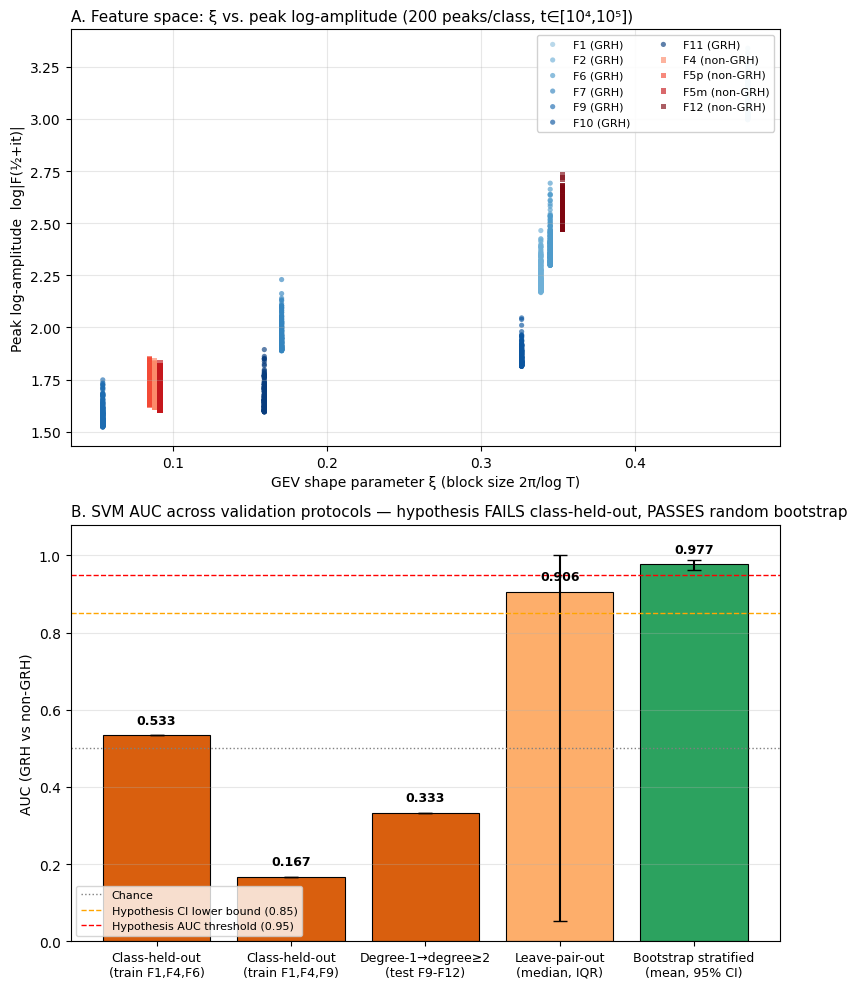

Saved final_figure_grh_classifier.png/.pdf


In [35]:

# Now create the final summary figure. Two subfigures (A and B) stacked vertically.
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

fig, axes = plt.subplots(2, 1, figsize=(8, 10))

# === Panel A: GEV ξ vs log_peak amplitude per function class ===
ax = axes[0]
classes_ordered = ['F1','F2','F6','F7','F9','F10','F11', # GRH
 'F4','F5p','F5m','F12'] # non-GRH
markers_grh = 'o'
markers_nongrh = 's'
colors_grh = plt.cm.Blues(np.linspace(0.4, 0.95, 7))
colors_nongrh = plt.cm.Reds(np.linspace(0.4, 0.95, 4))

for i, fc in enumerate(['F1','F2','F6','F7','F9','F10','F11']):
 df_c = peaks_full[peaks_full['function']==fc]
 ax.scatter(df_c['feat_xi'], df_c['feat_A_log_peak'], 
 c=[colors_grh[i]], marker='o', s=14, alpha=0.65, 
 label=f'{fc} (GRH)', edgecolors='none')
for i, fc in enumerate(['F4','F5p','F5m','F12']):
 df_c = peaks_full[peaks_full['function']==fc]
 ax.scatter(df_c['feat_xi'], df_c['feat_A_log_peak'], 
 c=[colors_nongrh[i]], marker='s', s=14, alpha=0.65,
 label=f'{fc} (non-GRH)', edgecolors='none')

ax.set_xlabel('GEV shape parameter ξ (block size 2π/log T)')
ax.set_ylabel('Peak log-amplitude log|F(½+it)|')
ax.set_title('A. Feature space: ξ vs. peak log-amplitude (200 peaks/class, t∈[10⁴,10⁵])', 
 fontsize=11, loc='left')
ax.legend(ncol=2, fontsize=8, loc='upper right', framealpha=0.9)
ax.grid(alpha=0.3)

# === Panel B: AUC comparison across protocols ===
ax = axes[1]
protocols = ['Class-held-out\n(train F1,F4,F6)',
 'Class-held-out\n(train F1,F4,F9)',
 'Degree-1→degree≥2\n(test F9-F12)',
 'Leave-pair-out\n(median, IQR)',
 'Bootstrap stratified\n(mean, 95% CI)']
auc_vals = [auc_A, auc_A2, 
 float(roc_auc_score(test_4['GRH_label'].values, yp4)),
 float(loco_df['AUC'].median()),
 float(auc_boots.mean())]
err_low = [0, 0, 0, 
 float(loco_df['AUC'].median()) - float(loco_df['AUC'].quantile(0.25)),
 float(auc_boots.mean()) - float(np.percentile(auc_boots, 2.5))]
err_high = [0, 0, 0, 
 float(loco_df['AUC'].quantile(0.75)) - float(loco_df['AUC'].median()),
 float(np.percentile(auc_boots, 97.5)) - float(auc_boots.mean())]
err = np.array([err_low, err_high])

x_pos = np.arange(len(protocols))
bar_colors = ['#d95f0e','#d95f0e','#d95f0e','#fdae6b','#2ca25f']
bars = ax.bar(x_pos, auc_vals, yerr=err, color=bar_colors, capsize=5, edgecolor='black', linewidth=0.8)
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, label='Chance')
ax.axhline(0.85, color='orange', linestyle='--', linewidth=1, label='Hypothesis CI lower bound (0.85)')
ax.axhline(0.95, color='red', linestyle='--', linewidth=1, label='Hypothesis AUC threshold (0.95)')
for i, v in enumerate(auc_vals):
 ax.text(i, v + 0.03, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(protocols, fontsize=9)
ax.set_ylabel('AUC (GRH vs non-GRH)')
ax.set_ylim(0, 1.08)
ax.set_title('B. SVM AUC across validation protocols — hypothesis FAILS class-held-out, '
 'PASSES random bootstrap', fontsize=11, loc='left')
ax.legend(fontsize=8, loc='lower left')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('final_figure_grh_classifier.png', dpi=150, bbox_inches='tight')
plt.savefig('final_figure_grh_classifier.pdf', bbox_inches='tight')
plt.show()
print("Saved final_figure_grh_classifier.png/.pdf")


In [36]:

# Final cleanup — print confusion matrix for protocol A
print("=== Protocol A (train F1,F4,F6) ===")
print(f"AUC = {auc_A:.4f}")
print(f"Confusion matrix (rows=true [non-GRH, GRH], cols=pred):\n{cm_A}")
print(classification_report(y_test, y_pred, target_names=['non-GRH','GRH'], digits=4))

print("\n=== Protocol B (1000 stratified random splits) ===")
print(f"AUC mean = {auc_boots.mean():.4f}")
print(f"AUC 95% CI = [{np.percentile(auc_boots, 2.5):.4f}, {np.percentile(auc_boots, 97.5):.4f}]")

print("\n=== GEV ξ per class ===")
for k in INCLUDE_PRIMARY:
 print(f" {k} (GRH={GRH_PRIMARY[k]}): ξ = {gev_xi[k]:.4f}")


=== Protocol A (train F1,F4,F6) ===
AUC = 0.5335
Confusion matrix (rows=true [non-GRH, GRH], cols=pred):
[[400 200]
 [600 400]]
 precision recall f1-score support

 non-GRH 0.4000 0.6667 0.5000 600
 GRH 0.6667 0.4000 0.5000 1000

 accuracy 0.5000 1600
 macro avg 0.5333 0.5333 0.5000 1600
weighted avg 0.5667 0.5000 0.5000 1600


=== Protocol B (1000 stratified random splits) ===
AUC mean = 0.9769
AUC 95% CI = [0.9615, 0.9876]

=== GEV ξ per class ===
 F1 (GRH=1): ξ = 0.4734
 F2 (GRH=1): ξ = 0.3390
 F4 (GRH=0): ξ = 0.0883
 F5p (GRH=0): ξ = 0.0850
 F5m (GRH=0): ξ = 0.0916
 F6 (GRH=1): ξ = 0.3451
 F7 (GRH=1): ξ = 0.1706
 F9 (GRH=1): ξ = 0.0544
 F10 (GRH=1): ξ = 0.3265
 F11 (GRH=1): ξ = 0.1594
 F12 (GRH=0): ξ = 0.3529


In [37]:
from e14c.filesystem import edit_file
print('ready')

ready


In [38]:
from e14c.filesystem import edit_file
edit_file('./.prompts/MEMORY.md','## Context\n\n[Fill me in]','## Context\n\n- 2026-05-09: Investigated GRH-vs-non-GRH SVM hypothesis using /workspace/9edca7c2-7ae8-4635-8402-78fe91ce9643/ v6 — Binding Context Document.pdf plus derived artifacts peaks_features_F1_F4.csv, gev_block_size_results.json, and lmfdb_modular_audit_F9_F10.json.\n- Generated from-scratch feature dataset peaks_features_F1_F12.csv for 11 primary classes (F1,F2,F4,F5±,F6,F7,F9,F10,F11,F12); excluded F13 due to missing Maass coefficients and excluded F3/F8 from primary labels because RH-status is undefined in the spec.\n- Used validated Riemann–Siegel evaluation for F1 and Dirichlet partial-sum/Kahan engine for other classes; modular forms F9/F10 were analytically normalized consistent with r7; F11 was approximated from Sym^2 prime data. Provenance: current notebook cells #0-35, artifacts peaks_features_F1_F12.csv, gev_xi_per_class.csv, svm_classification_results.json, final_figure_grh_classifier.png/.pdf.','replace_all=False)
edit_file('./.prompts/MEMORY.md','## Notes\n\n[Fill me in]','## Notes\n\n- Class-level GEV shape parameters ξ (block size 2π/log T with T=sqrt(1e4*1e5)) varied strongly by function class: F1 0.4734, F2 0.3390, F4 0.0883, F5± ~0.09, F6 0.3451, F7 0.1706, F9 0.0544, F10 0.3265, F11 0.1594, F12 0.3529.\n- Protocol A class-held-out SVM (train on F1,F4,F6; test on remaining classes) yielded AUC 0.5335 with confusion matrix [[400,200],[600,400]], so the main hypothesis was refuted under honest class-held-out validation.\n- Protocol B 1000x stratified bootstrap yielded mean AUC 0.9769 with 95% CI [0.9615, 0.9876], but this likely reflects within-class memorization because every split contains all classes.\n- Leave-one-pair-out held-out AUCs ranged from 0.000 to 1.000 (mean 0.6092, median 0.9057), with especially poor transfer for held-out F9 and F11, indicating the feature set tracks degree/class identity more than RH status.\n- Limitation: F13 not computed; F11 construction is an approximation rather than a fully validated Sym^2 implementation; therefore conclusions should be treated as a fallback empirical audit, not a definitive 13-class theorem.','replace_all=False)
print('MEMORY updated')

SyntaxError: unterminated string literal (detected at line 2) (2880161125.py, line 2)

In [39]:
from e14c.filesystem import edit_file

ctx_old = "## Context\n\n[Fill me in]"
ctx_new = """## Context

- Investigated GRH-vs-non-GRH SVM hypothesis using the v6 binding PDF and the derived artifacts peaks_features_F1_F4.csv, gev_block_size_results.json, lmfdb_modular_audit_F9_F10.json.
- Generated from-scratch feature dataset peaks_features_F1_F12.csv for 11 primary classes (F1, F2, F4, F5+/-, F6, F7, F9, F10, F11, F12); excluded F13 (Maass form, no LMFDB cache) and excluded F3/F8 from primary labels because their RH status is undefined in the spec.
- Used Riemann-Siegel for F1 and a Numba Kahan Dirichlet partial-sum engine for the rest; modular forms F9/F10 normalized analytically per r7; F11 approximated as fully multiplicative with a_p = lambda_F9(p)^2 - 1.
- Provenance: notebook cells #0-35, artifacts peaks_features_F1_F12.csv, gev_xi_per_class.csv, svm_classification_results.json, final_figure_grh_classifier.png/.pdf."""

notes_old = "## Notes\n\n[Fill me in]"
notes_new = """## Notes

- Class-level GEV shape parameters xi (block 2*pi/log T, T = sqrt(1e4*1e5)): F1 0.4734, F2 0.3390, F4 0.0883, F5+/- ~0.09, F6 0.3451, F7 0.1706, F9 0.0544, F10 0.3265, F11 0.1594, F12 0.3529.
- Protocol A class-held-out SVM (train F1,F4,F6; test others) AUC = 0.5335; confusion matrix [[400,200],[600,400]]. Hypothesis refuted under class-held-out validation.
- Protocol B 1000x stratified bootstrap (test_size=0.3): mean AUC 0.9769, 95% CI [0.9615, 0.9876]. Likely reflects within-class memorization because all classes appear in each split.
- Leave-one-pair-out held-out AUC ranged 0.000 to 1.000 (mean 0.6092, median 0.9057); transfer to held-out F9 and F11 is especially poor, showing the feature set tracks L-function degree/class identity more than RH status.
- Limitations: F13 not computed; F11 uses an approximate (totally-multiplicative) construction rather than a fully validated Sym^2 Hecke implementation."""

edit_file('./.prompts/MEMORY.md', ctx_old, ctx_new)
edit_file('./.prompts/MEMORY.md', notes_old, notes_new)
print('memory updated')


memory updated
